# サンプリング定理とエイリアシング

このノートはサンプリング定理 (Shannon-Nyquist) の観点からエイリアシングがどのように現れるかを確認するためのデモです。
十分に細かくサンプリングした連続時間信号と、ナイキスト周波数を下回るサンプリング周波数によって発生する折り返し (alias) を比較します。


## サンプリング定理の復習

- サンプリング周波数 $f_s$ は信号に含まれる最高周波数 $f_{max}$ の 2 倍以上である必要があります。
- 条件を満たさない場合、離散時間信号は別の低い周波数成分に見えてしまい、これをエイリアシングと呼びます。

下のセルではこの現象をシンプルなサイン波で再現します。


In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True


### シミュレーション用ユーティリティ
信号周波数 `f_signal`、サンプリング周波数 `f_s`、観測時間 `duration` を指定すると、滑らかな連続波形と離散サンプル列を返す関数です。


In [17]:
def simulate_signal(f_signal, fs, duration=5e-3, oversample=120):
    t_cont = np.linspace(0, duration, int(duration * fs * oversample), endpoint=False)
    x_cont = np.sin(2 * np.pi * f_signal * t_cont)
    t_sample = np.arange(0, duration, 1 / fs)
    x_sample = np.sin(2 * np.pi * f_signal * t_sample)
    return t_cont, x_cont, t_sample, x_sample

def alias_frequency(f_signal, fs):
    return abs(f_signal - np.round(f_signal / fs) * fs)


## 例: 1200 Hz のサイン波を 1 kHz でサンプリング
元のアナログ信号は $1200\,\mathrm{Hz}$ ですが、サンプリング周波数は $f_s = 1000\,\mathrm{Hz}$ しかないためナイキスト周波数 $f_s/2 = 500\,\mathrm{Hz}$ を満たしません。


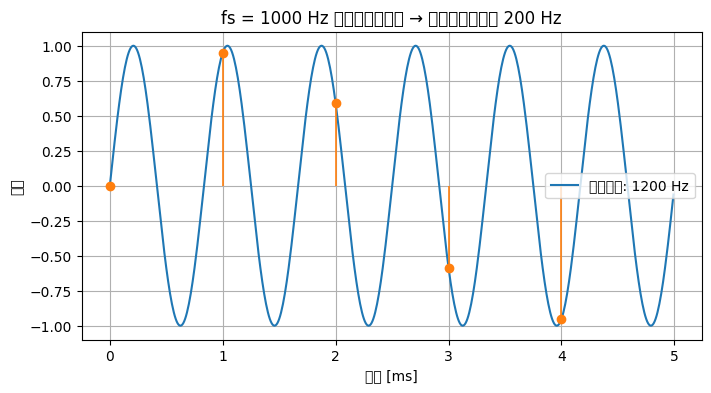

In [18]:
f_signal = 1200  # Hz
fs = 1000        # Hz
duration = 5e-3  # 秒

t_cont, x_cont, t_sample, x_sample = simulate_signal(f_signal, fs, duration)
f_alias = alias_frequency(f_signal, fs)

fig, ax = plt.subplots()
ax.plot(t_cont * 1e3, x_cont, label=f'連続時間: {f_signal} Hz')
markerline, stemlines, baseline = ax.stem(t_sample * 1e3, x_sample, linefmt='C1-', markerfmt='C1o', basefmt=' ')
plt.setp(stemlines, linewidth=1.2)
ax.set_xlabel('時間 [ms]')
ax.set_ylabel('振幅')
ax.set_title(f'fs = {fs} Hz でサンプリング → 折り返し周波数 {f_alias:.0f} Hz')
ax.legend()
plt.show()


サンプル列は $200\,\mathrm{Hz}$ のサイン波と完全に同じ並びになるため、スペクトル上では $200\,\mathrm{Hz}$ 成分として観測されます。これがエイリアシング（折り返し）の実体です。


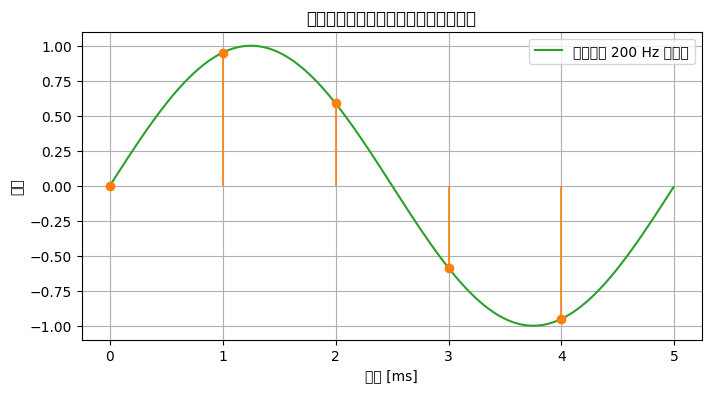

In [19]:
alias_wave = np.sin(2 * np.pi * f_alias * t_cont)

fig, ax = plt.subplots()
ax.plot(t_cont * 1e3, alias_wave, label=f'仮想的な {f_alias:.0f} Hz の波形', color='C2')
markerline, stemlines, baseline = ax.stem(t_sample * 1e3, x_sample, linefmt='C1-', markerfmt='C1o', basefmt=' ')
plt.setp(stemlines, linewidth=1.2)
ax.set_xlabel('時間 [ms]')
ax.set_ylabel('振幅')
ax.set_title('同じサンプル列は低い周波数に見える')
ax.legend()
plt.show()


オレンジ色の 200 Hz 波形と青色の 1200 Hz 波形はサンプル点では区別できません。そのため、復元時には 200 Hz の成分だと誤認してしまいます。


## ナイキスト条件を満たす場合
次に同じ信号を $f_s = 4000\,\mathrm{Hz}$ でサンプリングし、折り返しが発生しないケースを確認します。


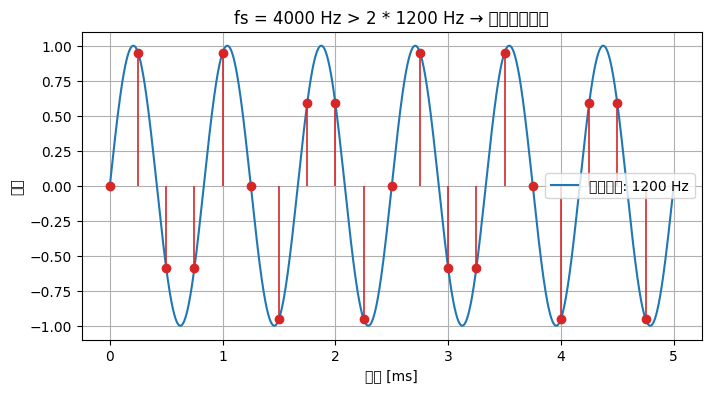

In [20]:
fs_safe = 4000
t_cont_safe, x_cont_safe, t_sample_safe, x_sample_safe = simulate_signal(f_signal, fs_safe, duration)

fig, ax = plt.subplots()
ax.plot(t_cont_safe * 1e3, x_cont_safe, label=f'連続時間: {f_signal} Hz')
markerline, stemlines, baseline = ax.stem(t_sample_safe * 1e3, x_sample_safe, linefmt='C3-', markerfmt='C3o', basefmt=' ')
plt.setp(stemlines, linewidth=1.2)
ax.set_xlabel('時間 [ms]')
ax.set_ylabel('振幅')
ax.set_title('fs = 4000 Hz > 2 * 1200 Hz → 折り返しなし')
ax.legend()
plt.show()


サンプリング周波数が十分に高いとサンプル点でも元の波形が忠実に追従していることが分かります。

パラメータ `f_signal` や `fs` を変更して、どの周波数で折り返しが発生するか試してみてください。例えば `f_signal = 1800` や `fs = 1500` などに書き換えると、折り返し周波数がどのように変わるかを確認できます。


## 周波数空間での確認
時間波形だけでなく、サンプル列の離散フーリエ変換 (DFT) を用いるとエイリアシングが周波数軸でどのように現れるかを視覚化できます。
ナイキストを満たさない場合は高周波成分が折り返して低周波のピークとして観測されます。


### FFT 用ユーティリティ
サンプル数が少ないと周波数分解能が粗くなるため、ゼロ詰め (zero padding) で補間したスペクトルを描画します。


In [21]:
def compute_spectrum(x_sample, fs, zero_pad=8):
    n = len(x_sample) * zero_pad
    X = np.fft.fft(x_sample, n=n)
    freqs = np.fft.fftfreq(n, d=1 / fs)
    pos = freqs >= 0
    scale = 2 / len(x_sample)
    return freqs[pos], np.abs(X[pos]) * scale

def plot_discrete_spectrum(freqs, magnitude, fs, ax=None, title='離散スペクトル'):
    if ax is None:
        fig, ax = plt.subplots()
    ax.stem(freqs, magnitude, linefmt='C4-', markerfmt='C4o', basefmt=' ')
    ax.set_xlim(0, fs / 2)
    ax.set_xlabel('周波数 [Hz]')
    ax.set_ylabel('振幅 (正規化)')
    ax.set_title(title)
    return ax


### 1 kHz で 1200 Hz をサンプリングしたときのスペクトル
離散スペクトル上では 1200 Hz のピークが 200 Hz に折り返して観測されることが分かります。


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35215 (\N{CJK UNIFIED IDEOGRAPH-898F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12383 (\N{HIRAGANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

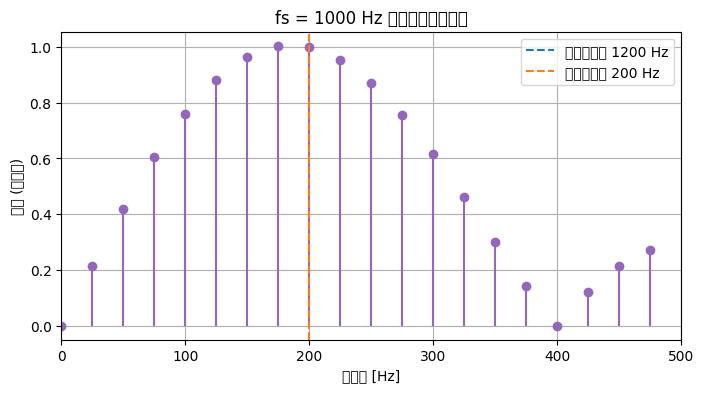

In [22]:
freqs_alias, mag_alias = compute_spectrum(x_sample, fs)
fig, ax = plt.subplots()
plot_discrete_spectrum(freqs_alias, mag_alias, fs, ax=ax, title='fs = 1000 Hz で得たスペクトル')
ax.axvline(f_signal, color='C0', linestyle='--', label=f'元の周波数 {f_signal} Hz')
ax.axvline(f_alias, color='C1', linestyle='--', label=f'エイリアス {f_alias:.0f} Hz')
ax.legend()
plt.show()


### 4 kHz でサンプリングした場合
十分なサンプリング周波数にすると、連続時間の 1200 Hz 成分がそのまま観測されます。


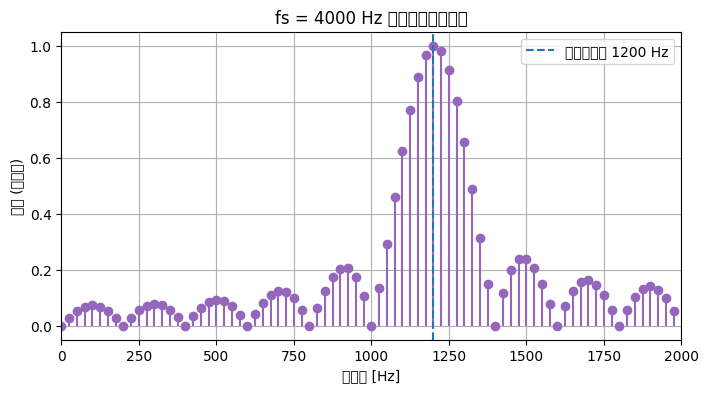

In [23]:
freqs_safe, mag_safe = compute_spectrum(x_sample_safe, fs_safe)
fig, ax = plt.subplots()
plot_discrete_spectrum(freqs_safe, mag_safe, fs_safe, ax=ax, title='fs = 4000 Hz で得たスペクトル')
ax.axvline(f_signal, color='C0', linestyle='--', label=f'元の周波数 {f_signal} Hz')
ax.legend()
plt.show()


時間領域と周波数領域の両方を観察することで、サンプル列がどの周波数に折り返して解釈されるかを定量的に捉えられます。
必要に応じて `zero_pad` や `f_signal` を変更し、分解能や折り返し位置の違いを試してみてください。
